## We will create a dataset that predicts whether a student passes or fails based on various features. Some of them are actually useful and some are just noise

In [100]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [101]:
np.random.seed(2)
n = 10000

In [102]:
df = pd.DataFrame({
    # Actually useful columns
    'study_hours': np.round(np.random.normal(loc=6, scale=2, size=n).clip(0, 12), 2),
    'sleep_hours': np.round(np.random.normal(loc=7, scale=1.5, size=n).clip(3, 10), 2),
    'attendance_pct': np.round(np.random.normal(loc=75, scale=15, size=n).clip(0, 100), 2),
    'prev_score': np.round(np.random.normal(loc=65, scale=15, size=n).clip(0, 100), 2),

    # Weekly useful variables
    'stress_level': np.random.randint(low=1, high=10, size=n),
    'exercise_days': np.random.randint(low=0, high=7, size=n),

    # Pure noise - Zero importance
    'student_id': np.arange(n),     # unique ID (high cardinality)
    'lucky_number': np.random.randint(low=1, high=50, size=n)
})

In [103]:
df.head()

,study_hours,sleep_hours,attendance_pct,prev_score,stress_level,exercise_days,student_id,lucky_number
0,5.17,5.79,74.72,62.74,2,4,0,29
1,5.89,6.20,69.60,62.68,8,5,1,29
2,1.73,6.56,78.52,21.07,9,4,2,35
3,9.28,6.47,64.36,72.64,3,5,3,28
4,2.41,4.05,91.38,71.14,2,2,4,2


In [104]:
# Create the target variable

# Pass/Fail based on a logical formula + some randomness
score = (
    df['study_hours']    * 4.0 +   # study matters most
    df['attendance_pct'] * 0.3 +   # attendance matters
    df['prev_score']     * 0.4 +   # past performance matters
    df['sleep_hours']    * 1.5 +   # sleep helps a bit
    np.random.normal(0, 5, n)      # some randomness
)
df['result'] = (score > score.median()).astype(int)

In [105]:
df.head()

,study_hours,sleep_hours,attendance_pct,prev_score,stress_level,exercise_days,student_id,lucky_number,result
0,5.17,5.79,74.72,62.74,2,4,0,29,0
1,5.89,6.20,69.60,62.68,8,5,1,29,0
2,1.73,6.56,78.52,21.07,9,4,2,35,0
3,9.28,6.47,64.36,72.64,3,5,3,28,1
4,2.41,4.05,91.38,71.14,2,2,4,2,0


In [106]:
# Distribution of the target variable
df["result"].value_counts()

result
0    5000
1    5000
Name: count, dtype: int64

#### Prepare Data

In [107]:
X = df.drop('result', axis=1)
y = df["result"]

In [108]:
feature_names = X.columns.tolist()
feature_names

['study_hours',
 'sleep_hours',
 'attendance_pct',
 'prev_score',
 'stress_level',
 'exercise_days',
 'student_id',
 'lucky_number']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

#### Train Random Forest

In [110]:
rf = RandomForestClassifier(n_estimators=200, random_state=2)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
print("Model Accuracy:", rf.score(X_test, y_test))

Model Accuracy: 0.8552


# Method 1 - Impurity based Importance

In [112]:
import matplotlib.pyplot as plt

# rf.feature_importances_ gives an array of importance scores
# One value per feature, all values sum equal to 1.0
importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importances)

study_hours       0.350203
prev_score        0.225892
attendance_pct    0.153743
sleep_hours       0.084998
student_id        0.067183
lucky_number      0.054493
stress_level      0.033775
exercise_days     0.029712
dtype: float64


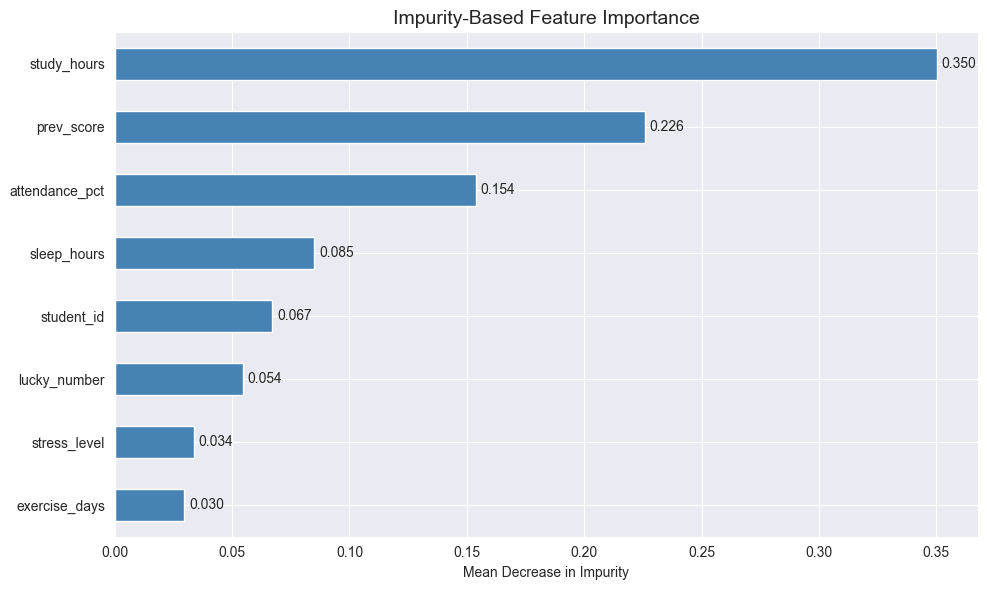

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")

# Add value labels on each bar
for i, val in enumerate(importances.sort_values()):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center')

ax.set_title("Impurity-Based Feature Importance", fontsize=14)
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

#### Why student_id gets higher score

In [114]:
# student_id has 10000 unique values (0 to 9999)
# → RF can always find a perfect split using it
#    e.g. "if student_id < 523 → pass"
# → Impurity drops a lot at that node
# → Gets high importance score
#
# But this is FAKE importance — it just memorized IDs!
# → This is the main weakness of impurity-based method

# Method 2 - Permutation Importance

In [115]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,     # Trained model
    X_test, # Use test data (not TRAIN, we want real performance)
    y_test,
    n_repeats=15, # Shuffle each feature 15 times and average the drops. More repeats = more stable
    random_state=2,
    n_jobs=-1   # Use all CPU cores
)

# result.importances_mean --> average drop in accuracy per feature
# result.importances_std --> how stable the drop was across repeats

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean,
    "std": result.importances_std,
}).sort_values("importance", ascending=False)

print(perm_imp)

          feature  importance       std
0     study_hours    0.219547  0.010260
3      prev_score    0.132373  0.006347
2  attendance_pct    0.081387  0.004927
1     sleep_hours    0.019467  0.005409
5   exercise_days    0.000693  0.002208
6      student_id   -0.001440  0.002007
4    stress_level   -0.002640  0.001091
7    lucky_number   -0.002693  0.001978


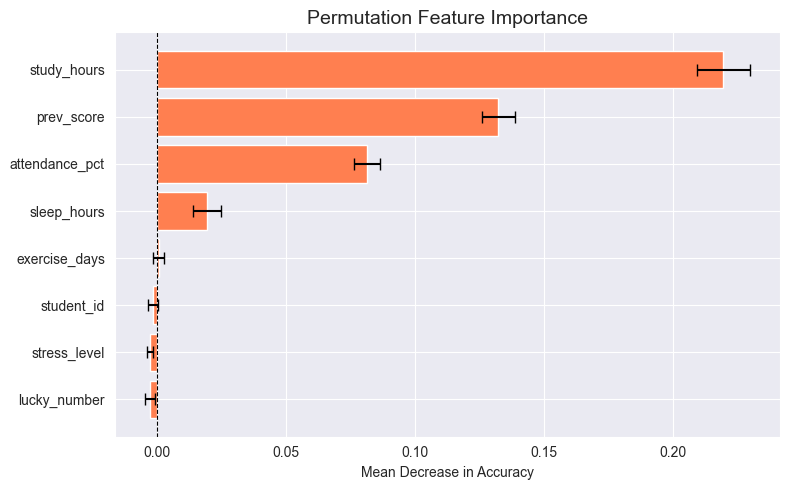

In [116]:
# Plot with error bars
perm_sorted = perm_imp.sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    perm_sorted['feature'],
    perm_sorted['importance'],
    xerr=perm_sorted['std'],   # error bars show stability
                               # wide bar = unstable score
    color='coral',
    capsize=4
)

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Permutation Feature Importance", fontsize=14)
ax.set_xlabel("Mean Decrease in Accuracy")
plt.tight_layout()
plt.show()

# Narrow error bar --> Importance score is consistent and reliable
# Wide error bar --> Importance score varies a lot --> treat with caution



# Method 3 - Drop-Column Importance

In [117]:
from sklearn.ensemble import RandomForestClassifier

# Step 1 — baseline accuracy with ALL features
baseline_score = rf.score(X_test, y_test)
print(f"Baseline Accuracy: {baseline_score:.4f}")

drop_importances = {}

# Step 2 — drop one feature at a time, retrain, compare
for feature in feature_names:

    # Remove this feature from train and test
    X_train_dropped = X_train.drop(columns=[feature])
    X_test_dropped  = X_test.drop(columns=[feature])

    # Train a fresh model WITHOUT this feature
    # (we retrain because the model needs to adjust)
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_temp.fit(X_train_dropped, y_train)

    # Score without this feature
    dropped_score = rf_temp.score(X_test_dropped, y_test)

    # Importance = how much accuracy we LOST by dropping it
    drop_importances[feature] = baseline_score - dropped_score

    print(f"Dropped {feature:20s} → Score: {dropped_score:.4f}  "
          f"| Importance: {baseline_score - dropped_score:+.4f}")

Baseline Accuracy: 0.8552
Dropped study_hours          → Score: 0.7064  | Importance: +0.1488
Dropped sleep_hours          → Score: 0.8484  | Importance: +0.0068
Dropped attendance_pct       → Score: 0.8052  | Importance: +0.0500
Dropped prev_score           → Score: 0.7688  | Importance: +0.0864
Dropped stress_level         → Score: 0.8632  | Importance: -0.0080
Dropped exercise_days        → Score: 0.8520  | Importance: +0.0032
Dropped student_id           → Score: 0.8584  | Importance: -0.0032
Dropped lucky_number         → Score: 0.8576  | Importance: -0.0024


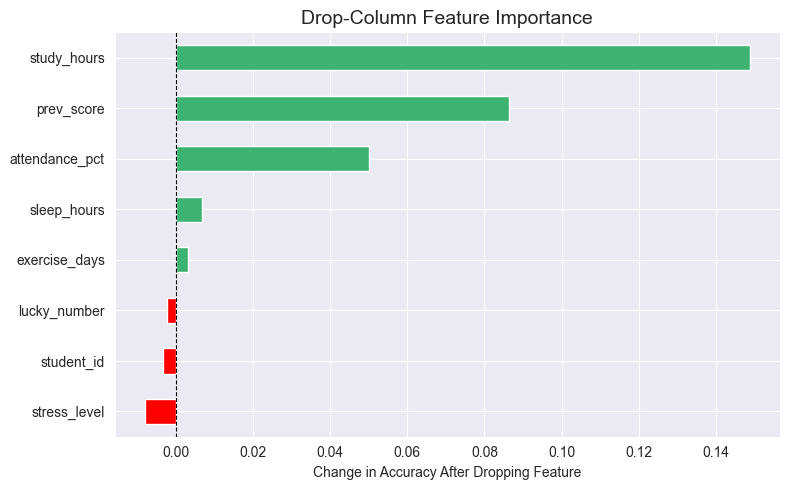

In [118]:
drop_series = pd.Series(drop_importances).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['red' if v < 0 else 'mediumseagreen' for v in drop_series]

drop_series.plot(kind='barh', ax=ax, color=colors)

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Drop-Column Feature Importance", fontsize=14)
ax.set_xlabel("Change in Accuracy After Dropping Feature")
plt.tight_layout()
plt.show()